In [3]:
import pandas as pd
import numpy as np

In [4]:
data = {
    'x1':[1, np.nan, 3, 4, np.nan, np.nan, np.nan, 11, 12, 13],
    'y1':[1, 2, 3, 4, np.nan, np.nan, np.nan, 8, 9, 10],
    'x2':[1, 2, 3, 4, 5, np.nan, np.nan, 8, 9, 10],
    'y2':[np.nan, 2, 3, 4, 5, 6, np.nan, 8, 9, 10],
}

In [5]:
df = pd.DataFrame(data)

In [7]:
df.head(10)

,x1,y1,x2,y2
0,1.0,1.0,1.0,NaN
1,NaN,2.0,2.0,2.0
2,3.0,3.0,3.0,3.0
3,4.0,4.0,4.0,4.0
4,NaN,NaN,5.0,5.0
5,NaN,NaN,NaN,6.0
6,NaN,NaN,NaN,NaN
7,11.0,8.0,8.0,8.0
8,12.0,9.0,9.0,9.0
9,13.0,10.0,10.0,10.0


In [8]:
df.interpolate()

,x1,y1,x2,y2
0,1.00,1.0,1.0,NaN
1,2.00,2.0,2.0,2.0
2,3.00,3.0,3.0,3.0
3,4.00,4.0,4.0,4.0
4,5.75,5.0,5.0,5.0
5,7.50,6.0,6.0,6.0
6,9.25,7.0,7.0,7.0
7,11.00,8.0,8.0,8.0
8,12.00,9.0,9.0,9.0
9,13.00,10.0,10.0,10.0


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a sample dataset
np.random.seed(42)
n = 1000
data = pd.DataFrame({
    "Order_ID": range(1, n+1),
    "Customer_ID": np.random.randint(1000, 2000, size=n),
    "Restaurant_Type": np.random.choice(["Fast Food", "Fine Dining", "Casual", "Cafe"], size=n),
    "Delivery_Zone": np.random.choice(["Zone A", "Zone B", "Zone C"], size=n),
    "Time_Slot": np.random.choice(["Morning", "Lunch", "Evening", "Night"], size=n),
    "ETA_Minutes": np.random.randint(20, 50, size=n),
})

# Simulate actual delivery time with some delays
data["Delay_Minutes"] = np.random.normal(loc=5, scale=7, size=n).astype(int)
data["Delay_Minutes"] = data["Delay_Minutes"].apply(lambda x: max(0, x))
data["Actual_Delivery_Minutes"] = data["ETA_Minutes"] + data["Delay_Minutes"]

# Simulate customer ratings based on delay (more delay, lower rating on avg)
base_ratings = 5 - (data["Delay_Minutes"] / 10) + np.random.normal(0, 0.5, n)
data["Customer_Rating"] = base_ratings.clip(1, 5).round(1)

# Add order date
date_range = pd.date_range(start="2023-01-01", periods=n//10)
data["Order_Date"] = np.random.choice(date_range, size=n)

# Quick overview
summary = data.describe(include='all')


data.head()

,Order_ID,Customer_ID,Restaurant_Type,Delivery_Zone,Time_Slot,ETA_Minutes,Delay_Minutes,Actual_Delivery_Minutes,Customer_Rating,Order_Date
0,1,1102,Fast Food,Zone B,Morning,22,3,25,4.2,2023-01-31
1,2,1435,Fast Food,Zone C,Evening,23,0,23,4.5,2023-02-09
2,3,1860,Casual,Zone A,Lunch,45,0,45,4.8,2023-02-17
3,4,1270,Cafe,Zone C,Evening,44,0,44,4.3,2023-02-20
4,5,1106,Fast Food,Zone B,Lunch,34,0,34,4.7,2023-02-12


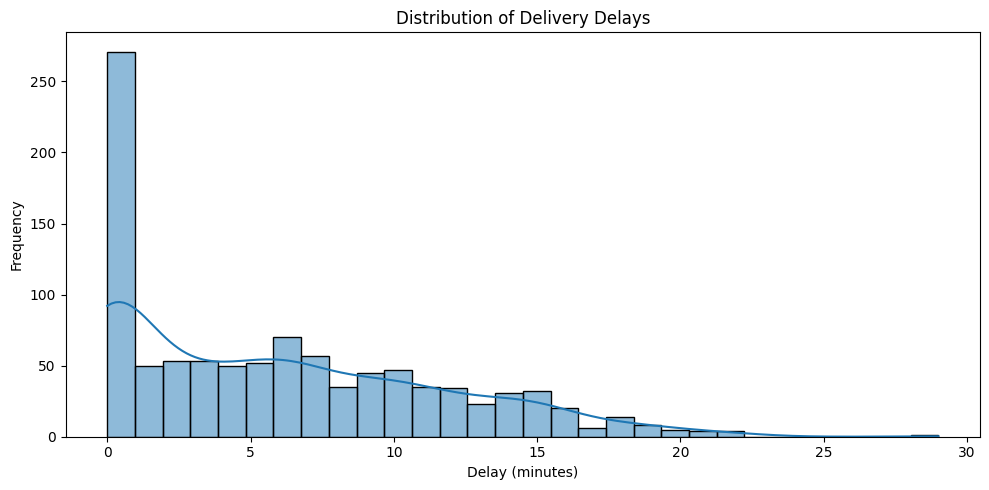

In [2]:
plt.figure(figsize=(10, 5))
sns.histplot(data["Delay_Minutes"], bins=30, kde=True)
plt.title("Distribution of Delivery Delays")
plt.xlabel("Delay (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()

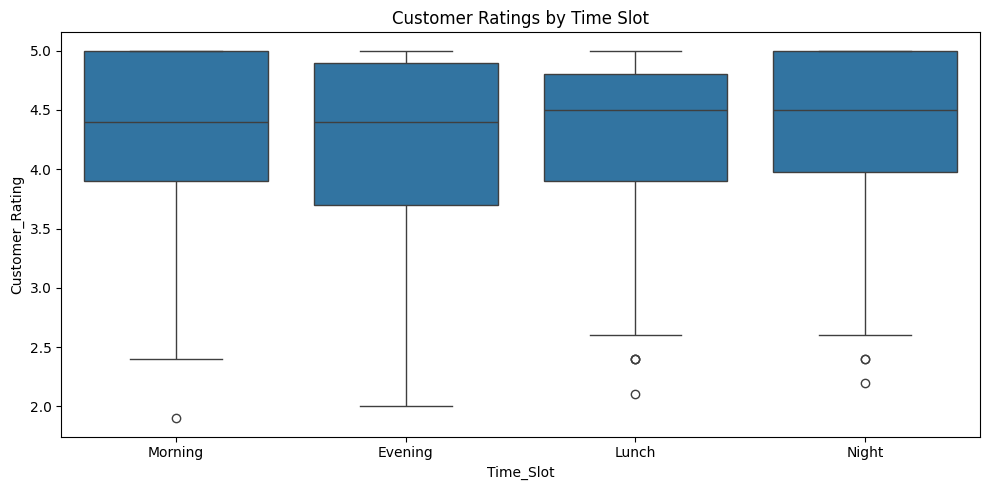

In [3]:
plt.figure(figsize=(10, 5))
sns.boxplot(x="Time_Slot", y="Customer_Rating", data=data)
plt.title("Customer Ratings by Time Slot")
plt.tight_layout()

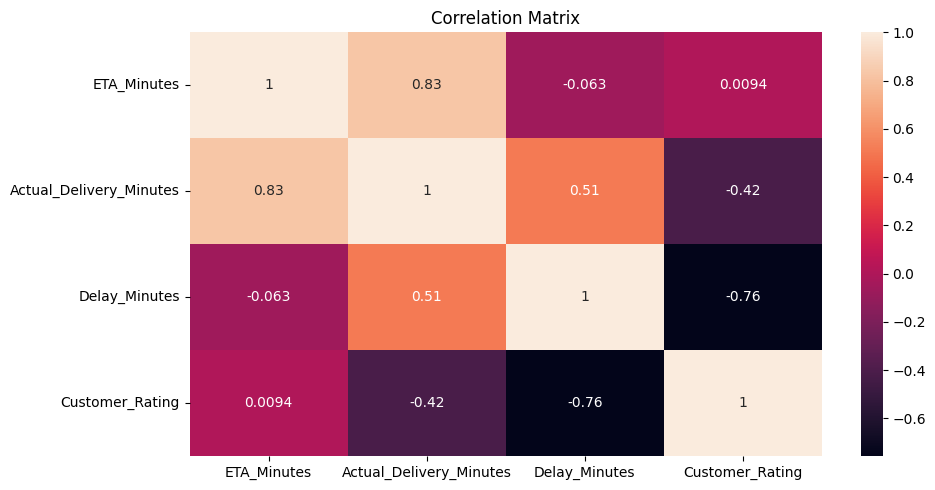

In [4]:
plt.figure(figsize=(10, 5))
sns.heatmap(data[["ETA_Minutes", "Actual_Delivery_Minutes", "Delay_Minutes", "Customer_Rating"]].corr(), annot=True)
plt.title("Correlation Matrix")
plt.tight_layout()

In [6]:
data.head()

,Order_ID,Customer_ID,Restaurant_Type,Delivery_Zone,Time_Slot,ETA_Minutes,Delay_Minutes,Actual_Delivery_Minutes,Customer_Rating,Order_Date
0,1,1102,Fast Food,Zone B,Morning,22,3,25,4.2,2023-01-31
1,2,1435,Fast Food,Zone C,Evening,23,0,23,4.5,2023-02-09
2,3,1860,Casual,Zone A,Lunch,45,0,45,4.8,2023-02-17
3,4,1270,Cafe,Zone C,Evening,44,0,44,4.3,2023-02-20
4,5,1106,Fast Food,Zone B,Lunch,34,0,34,4.7,2023-02-12
